In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# !export PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT=2

### Load packages and data

In [31]:
import spatialdata_io
import matplotlib.pyplot as plt
import spatialdata as sd
import segtraq
import spatialdata_plot
import scanpy as sc
import seaborn as sns
import anndata as ad
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import dask.dataframe as dd
import glob
from dask import delayed

from spatialdata.models import PointsModel
import statsmodels.api as sm
from pathlib import Path
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

In [32]:
sdata = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr/")


In [33]:
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

# st = segtraq.SegTraQ(
#     sdata,
#     points_cell_id_key="assignment",
#     points_background_id=None,
#     points_gene_key="gene",
#     tables_area_key=None,
#     tables_cell_id_key="cell",
#     shapes_cell_id_key="cell",
#     tables_centroid_x_key="centroid_x",
#     tables_centroid_y_key="centroid_y",
# )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


In [34]:
# sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")

# bb_xmin = 800
# bb_ymin = 1150
# bb_w = 200
# bb_h = 300
# bb_xmax = bb_xmin + bb_w
# bb_ymax = bb_ymin + bb_h

# def crop(ws):
#     return ws.query.bounding_box(
#         axes=["x", "y"],
#         min_coordinate=[bb_xmin, bb_ymin],
#         max_coordinate=[bb_xmax, bb_ymax],
#         target_coordinate_system="global",
#     )
# sdata = crop(sdata_bidcell_ws)

# st = segtraq.SegTraQ(
#     sdata,
#     images_key="image",
#     points_background_id=0,
#     tables_centroid_x_key="centroid_x",
#     tables_centroid_y_key="centroid_y",
# )

## Compute baseline metrics

In [35]:
%%time
st.run_baseline()

CPU times: user 328 ms, sys: 13.7 ms, total: 342 ms
Wall time: 349 ms


## Mixture fit

This metric quantifies whether the **border expression profile** of a cell can be explained as a mixture of its own **center** and the **local neighborhood**.

#### Overview
For each cell, the method:

1. **Computes three expression profiles**
   - **center**: transcripts in the eroded interior of the cell
   - **border**: transcripts in the outer ring of the cell
   - **neighborhood**: aggregated expression of nearby cells within a specified radius

2. **Restricts to a shared gene space**
   - Only genes detected in at least one of the three regions are retained.
   - Cells with too few transcripts or too few genes are excluded.

3. **Converts counts to normalized proportions**
   - Raw counts are transformed into gene-expression proportions (optionally with pseudocount smoothing),
     so the model focuses on **composition** rather than absolute transcript count.

4. **Fits a center–neighborhood mixture model**
   - The border profile is modeled as:
     
     $$
     p_{\mathrm{border}} = (1-\alpha)\, p_{\mathrm{center}} + \alpha\, p_{\mathrm{neighborhood}}
     $$
     
   - The parameter **\(\alpha\)** is estimated by least squares and interpreted as the fraction of the border profile that is neighborhood-like.

5. **Quantifies how well the mixture explains the border**
   - The method compares:
     - a **center-only model** (border ≈ center)
     - the **best-fitting mixture model** (border ≈ center + neighborhood)
   - It reports the improvement in fit when neighborhood contribution is allowed.

#### Main outputs
- **`mixture_alpha_hat`**  
  Estimated contamination fraction. Higher values indicate the border is more similar to the neighborhood.

- **`mixture_fit_improvement_fraction`**  
  Fraction of the border mismatch (relative to center alone) that is explained by the mixture model.

Together, these outputs help distinguish cells whose borders are simply different from the center from cells whose borders are specifically **consistent with local contamination**.

In [36]:
st.rs.border_admixture_score()

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The p

,cell_id,border_admixture_score,alpha_hat,n_center,n_border,n_neighborhood,n_genes_used,border_admixture_score_ci_low,border_admixture_score_ci_high,n_neighbors
0,6327,0.360740,0.459035,238,125,999,183,0.171390,0.556872,4
1,6328,0.258559,0.285198,90,72,2337,222,0.123390,0.497520,6
2,6330,0.024260,0.172236,207,107,1020,189,0.011356,0.315596,2
3,6331,0.480440,0.577976,288,152,2024,224,0.282396,0.602062,6
4,6332,0.190725,0.742198,170,109,1902,223,0.114575,0.504993,5
...,...,...,...,...,...,...,...,...,...,...
1557,95953,0.728627,0.814986,91,114,1534,201,0.466775,0.757122,10
1558,95954,0.455449,0.389371,47,18,624,152,0.283805,0.623250,6
1559,95955,0.011305,0.106989,45,24,918,173,0.008950,0.354646,7
1560,95959,0.277246,0.280254,38,15,873,167,0.168975,0.550716,6


In [37]:
sdata.tables["table"].obs["n_neighbors"].mean()

np.float64(8.524967989756723)

In [38]:
features = ([
             'border_admixture_score',
             'border_admixture_score_ci_low', 
             'border_admixture_score_ci_high', 
             'alpha_hat',
             'transcript_count'])

cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "xenium"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(1563, 6)


,border_admixture_score,border_admixture_score_ci_low,border_admixture_score_ci_high,alpha_hat,transcript_count,sample
0,0.360740,0.171390,0.556872,0.459035,420.0,xenium
1,0.258559,0.123390,0.497520,0.285198,201.0,xenium
2,0.024260,0.011356,0.315596,0.172236,391.0,xenium
3,0.480440,0.282396,0.602062,0.577976,512.0,xenium
4,0.190725,0.114575,0.504993,0.742198,345.0,xenium


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def plot_rs_against_counts(cell_df, xcol, ycols):
    plot_df = cell_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol] + ycols)
    plot_df = plot_df[plot_df[xcol] >= 0]

    n_cols = min(3, len(ycols))
    n_rows = int(np.ceil(len(ycols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=False,
        sharey=False
    )

    # make axes always 2D
    axes = np.atleast_2d(axes)

    for j, ycol in enumerate(ycols):
        i, k = divmod(j, n_cols)
        ax = axes[i, k]

        sns.scatterplot(
            data=plot_df,
            x=xcol,
            y=ycol,
            alpha=0.25,
            s=10,
            linewidth=0,
            ax=ax,
            color="black"
        )

        X = sm.add_constant(plot_df[xcol].to_numpy())
        y = plot_df[ycol].to_numpy()

        if len(X) > 1:
            model = sm.OLS(y, X, missing="drop").fit()
            r2 = model.rsquared

            xs = np.linspace(plot_df[xcol].min(), plot_df[xcol].max(), 200)
            ys = model.predict(sm.add_constant(xs))

            ax.plot(xs, ys, color="red")
            title = f"{ycol}\n$R^2$={r2:.3f}"
        else:
            title = ycol

        ax.set_title(title)

        if i == n_rows - 1:
            ax.set_xlabel(xcol)
        else:
            ax.set_xlabel("")

    # hide unused axes
    total_axes = n_rows * n_cols
    for j in range(len(ycols), total_axes):
        i, k = divmod(j, n_cols)
        axes[i, k].set_visible(False)

    plt.tight_layout()
    plt.show()

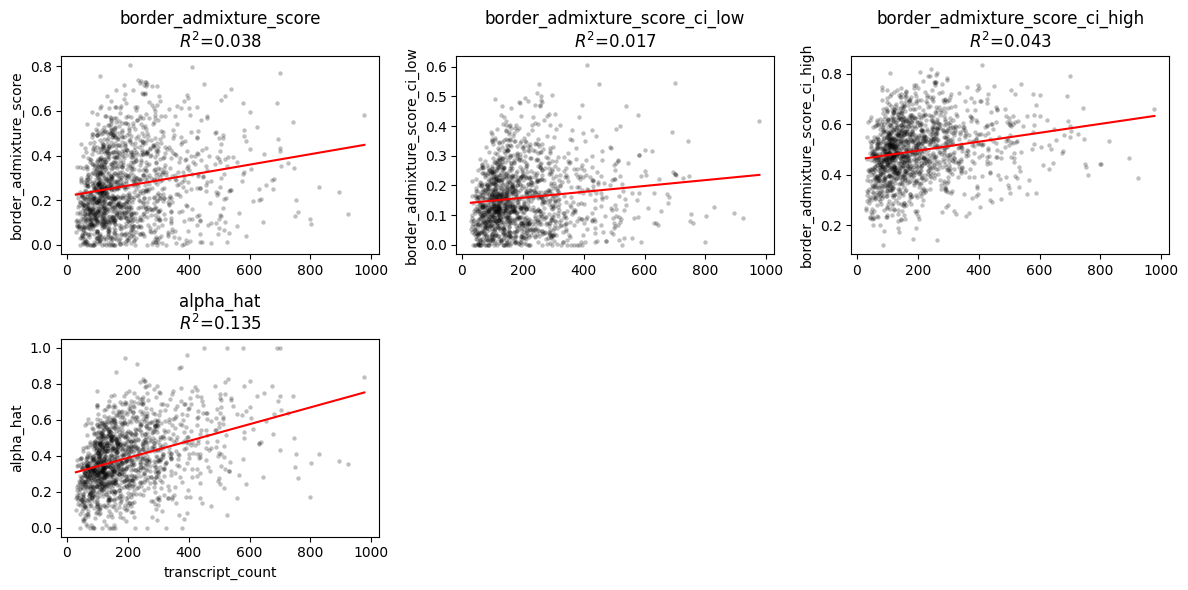

In [40]:
plot_rs_against_counts(cell_df, "transcript_count",
                       ycols=[
                    'border_admixture_score',
                    'border_admixture_score_ci_low', 
                    'border_admixture_score_ci_high', 
                    'alpha_hat',
                    ])

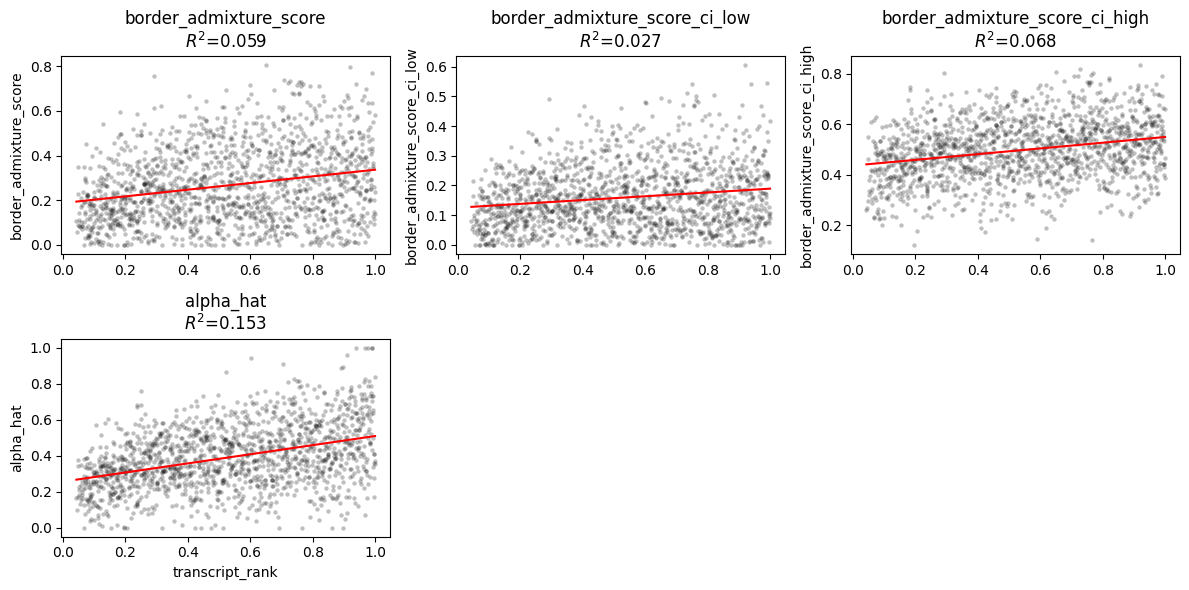

In [41]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts(cell_df, "transcript_rank",
                       ycols=[
                    'border_admixture_score',
                    'border_admixture_score_ci_low', 
                    'border_admixture_score_ci_high', 
                    'alpha_hat',
                    ])

In [42]:
import numpy as np
import matplotlib.pyplot as plt


def plot_metric_with_confidence_intervals(
    cell_df,
    metric: str = "border_admixture_score",
    figsize: tuple[float, float] = (6, 5),
    markersize: float = 20,
    transcript_count_col: str = "transcript_count",
):
    """
    Scatter plot of observed metric vs transcript rank, with vertical lines showing
    the bootstrap confidence interval.

    Cells where CI_low > mean(metric) are highlighted in red.
    """
    df = cell_df.copy()

    y_col = metric
    q_low_col = f"{metric}_ci_low"
    q_high_col = f"{metric}_ci_high"

    required_cols = [y_col, q_low_col, q_high_col, transcript_count_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    df = df[required_cols].dropna().copy()

    # compute threshold
    mean_val = df[y_col].mean()

    # x-axis = transcript rank
    df = df.sort_values(transcript_count_col).reset_index(drop=True)
    df["transcript_rank"] = np.arange(1, len(df) + 1)

    x = df["transcript_rank"].to_numpy()
    y = df[y_col].to_numpy()
    q_low = df[q_low_col].to_numpy()
    q_high = df[q_high_col].to_numpy()

    # condition of interest
    flagged = q_low > mean_val
    not_flagged = ~flagged

    fig, ax = plt.subplots(figsize=figsize)

    # CI bars
    ax.vlines(
        x=x[not_flagged],
        ymin=q_low[not_flagged],
        ymax=q_high[not_flagged],
        alpha=0.2,
        linewidth=0.8,
    )

    ax.vlines(
        x=x[flagged],
        ymin=q_low[flagged],
        ymax=q_high[flagged],
        alpha=0.6,
        color="red",
        linewidth=1.0,
    )

    # observed points
    ax.scatter(
        x[not_flagged],
        y[not_flagged],
        alpha=0.4,
        s=markersize,
        label="others",
    )

    ax.scatter(
        x[flagged],
        y[flagged],
        alpha=0.9,
        s=markersize,
        color="red",
        label="CI_low > mean",
    )

    # optional: show the mean threshold
    ax.axhline(mean_val, linestyle="--", linewidth=1)
    
    ax.set_xlabel("Transcript rank")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} with confidence intervals\n(red: CI_low > mean)")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

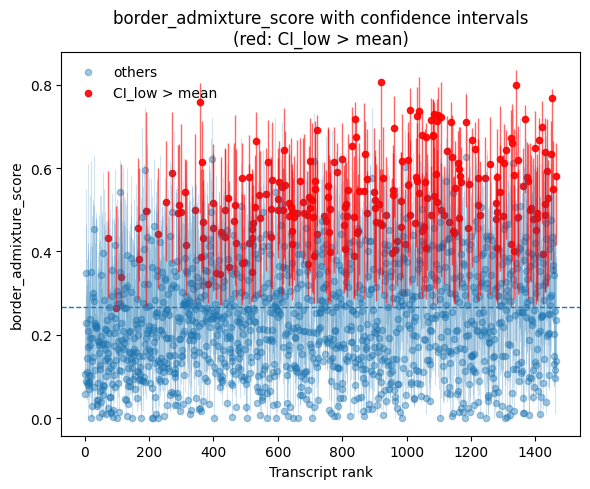

In [43]:
plot_metric_with_confidence_intervals(
    cell_df=cell_df,
    metric="border_admixture_score",
    transcript_count_col="transcript_count",
)

## Spatial visualizations

In [44]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

In [45]:
st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:771: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["counts"]`.
  result = _run_label_transfer(


In [46]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

In [47]:
# Replace NaN with Unknown for plotting

s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

/tmp/ipykernel_451690/3220636980.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


In [48]:
def plot_feature_labels(sdata, method, feature, axes):
    labels = sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_celltype_plot",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=feature,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[1], title=f"{method}: {feature}", coordinate_systems="global")

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


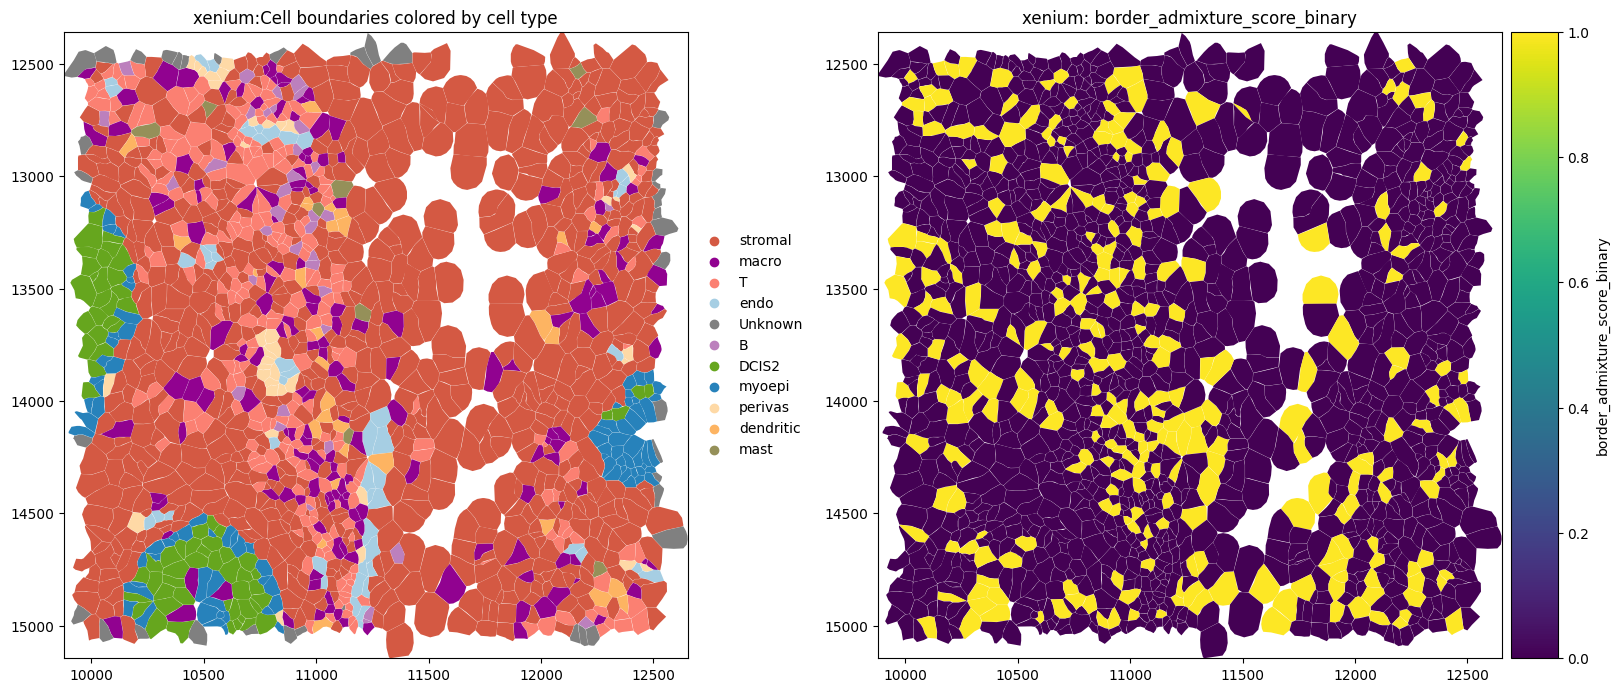

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
#axes = np.atleast_2d(axes)
sdata.tables["table"].obs["border_admixture_score_binary"] = sdata.tables["table"].obs["border_admixture_score_ci_low"] > sdata.tables["table"].obs["border_admixture_score"].median()
plot_feature_labels(sdata, "xenium", "border_admixture_score_binary", axes)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


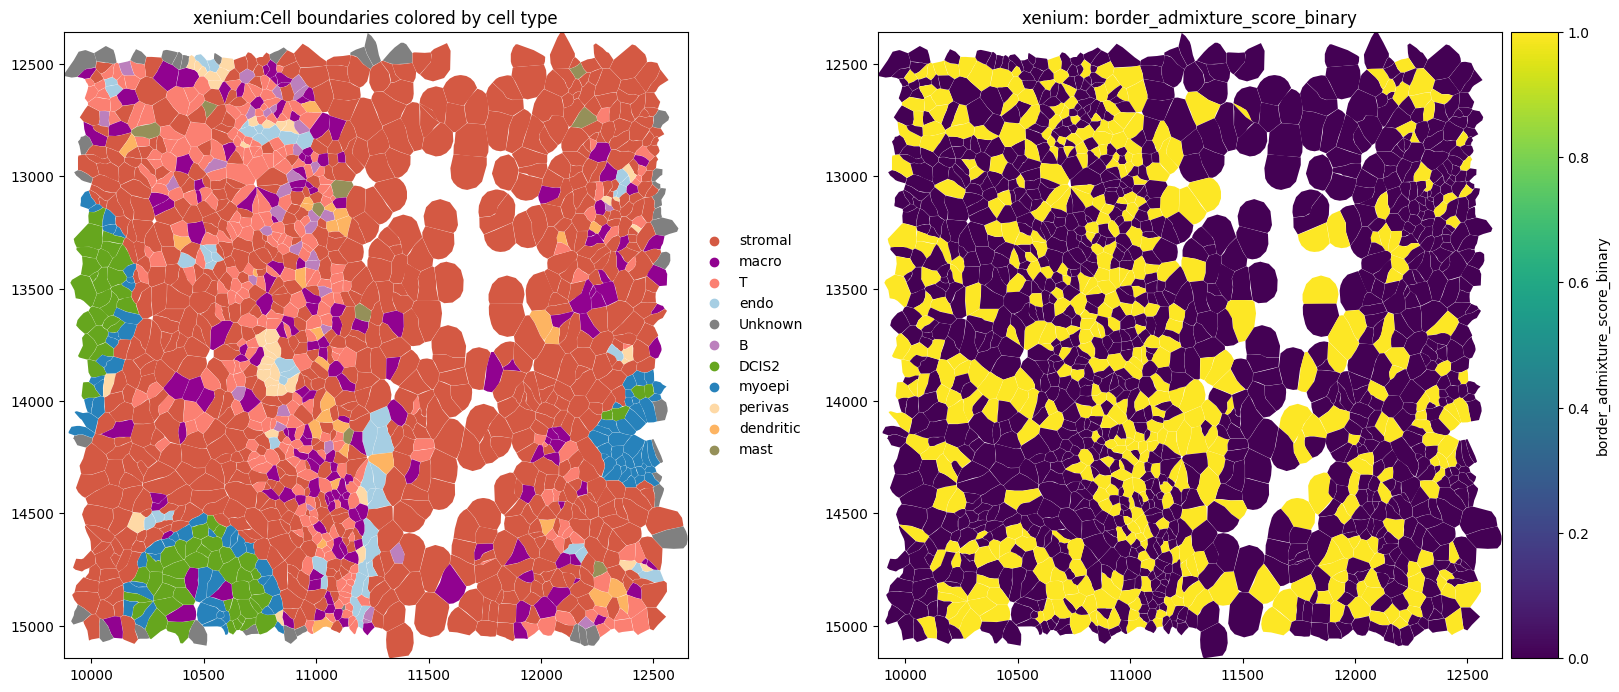

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
#axes = np.atleast_2d(axes)
sdata.tables["table"].obs["border_admixture_score_binary"] = sdata.tables["table"].obs["border_admixture_score_ci_low"] > 0.2
plot_feature_labels(sdata, "xenium", "border_admixture_score_binary", axes)

In [56]:
# method for visualization
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

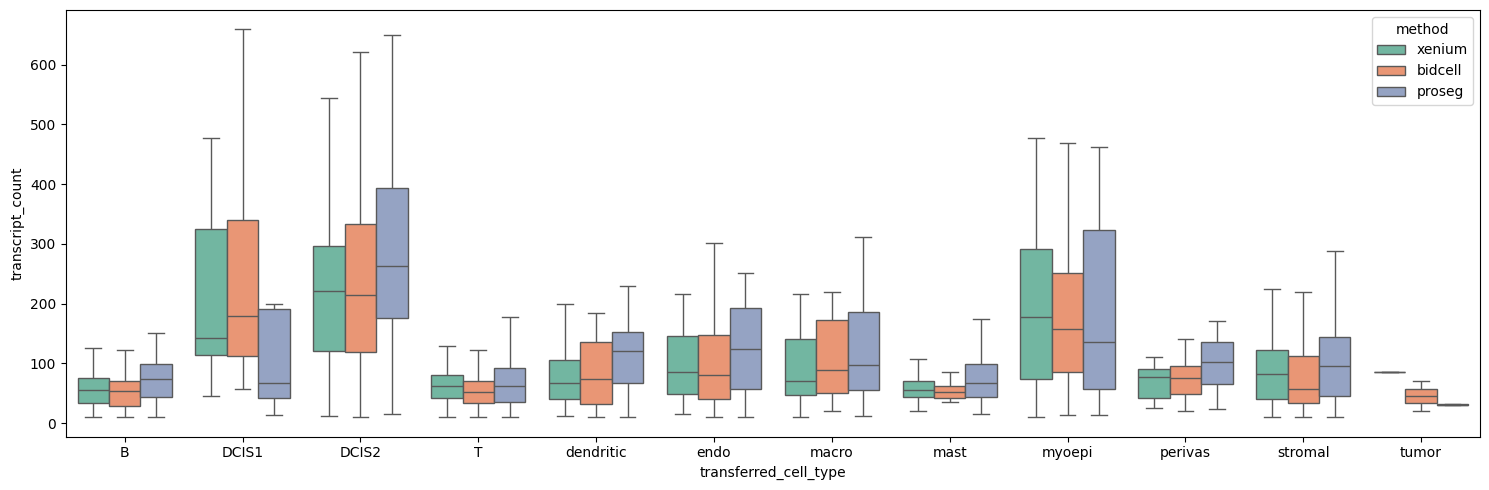

In [57]:
boxplot_per_celltype(st_dict, "transcript_count")

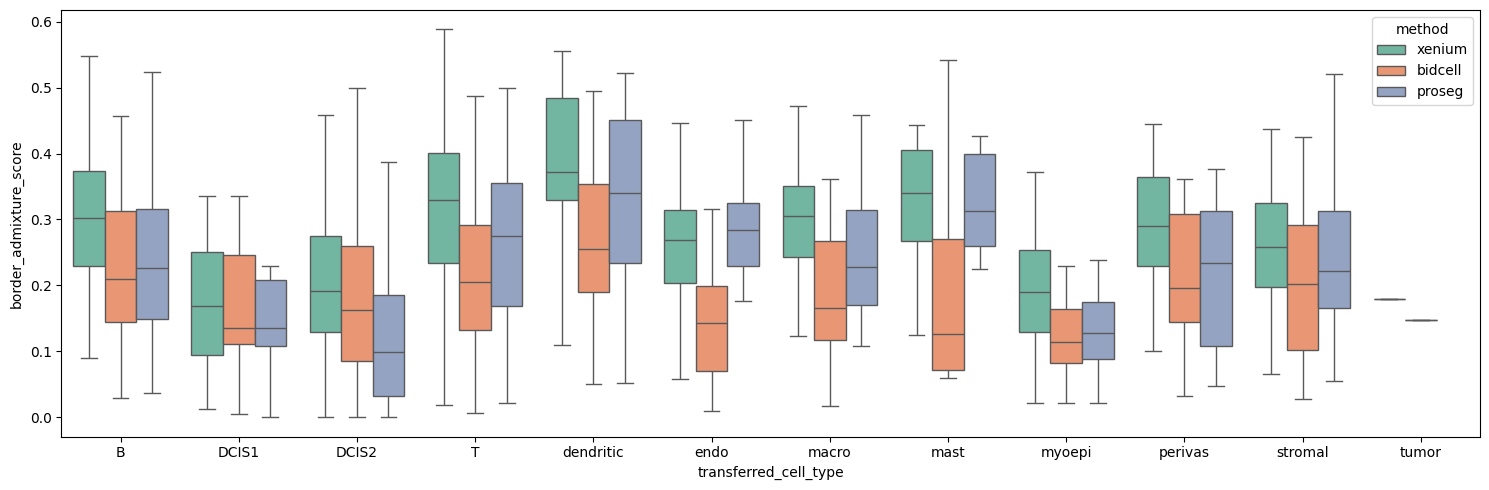

In [58]:
boxplot_per_celltype(st_dict, "border_admixture_score")

In [51]:
import math

from segtraq.rs.utils import _get_center_border_counts, _get_neighborhood_counts


def _normalize_with_pseudocount(x: np.ndarray, pseudocount: float = 0.5) -> np.ndarray:
    x = np.asarray(x, dtype=float).ravel()
    x = x + pseudocount
    total = x.sum()
    if total <= 0:
        return np.zeros_like(x, dtype=float)
    return x / total


def _get_top_genes_for_cell(
    sdata,
    cid,
    n_genes: int = 6,
    mode: str = "absolute",  # "absolute", "neighborhood_vs_center", "both_directions"
    tables_key: str = "table",
    tables_cell_id_key: str = "cell_id",
    expr_center_raw: pd.DataFrame | None = None,
    expr_neighborhood_raw: pd.DataFrame | None = None,
    pseudocount: float = 0.5,
):
    """
    Select top genes for one cell.

    Parameters
    ----------
    mode : str
        "absolute":
            top genes by absolute whole-cell counts

        "neighborhood_vs_center":
            top genes with largest (p_neighborhood - p_center)

        "both_directions":
            balanced set of genes from both directions:
            - top genes with largest (p_neighborhood - p_center)
            - top genes with largest (p_center - p_neighborhood)
    """
    obs = sdata[tables_key].obs
    mask = obs[tables_cell_id_key] == cid
    if mask.sum() == 0:
        return []

    if mode == "absolute":
        adata_sub = sdata[tables_key][mask, :]
        X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
        expr_vector = np.asarray(X).ravel()

        nonzero = expr_vector > 0
        if nonzero.sum() == 0:
            return []

        genes_nonzero = adata_sub.var_names[nonzero]
        expr_nonzero = expr_vector[nonzero]

        return (
            pd.Series(expr_nonzero, index=genes_nonzero)
            .sort_values(ascending=False)
            .head(n_genes)
            .index
            .tolist()
        )

    if mode in {"neighborhood_vs_center", "both_directions"}:
        if expr_center_raw is None or expr_neighborhood_raw is None:
            raise ValueError(
                "`expr_center_raw` and `expr_neighborhood_raw` must be provided "
                f"for mode={mode!r}."
            )

        if cid not in expr_center_raw.index or cid not in expr_neighborhood_raw.index:
            return []

        common_genes = expr_center_raw.columns.intersection(expr_neighborhood_raw.columns)
        if len(common_genes) == 0:
            return []

        x_center = expr_center_raw.loc[cid, common_genes].to_numpy(dtype=float)
        x_neighborhood = expr_neighborhood_raw.loc[cid, common_genes].to_numpy(dtype=float)

        p_center = _normalize_with_pseudocount(x_center, pseudocount=pseudocount)
        p_neighborhood = _normalize_with_pseudocount(x_neighborhood, pseudocount=pseudocount)

        delta = pd.Series(p_neighborhood - p_center, index=common_genes)

        # keep only genes present in at least one of the two profiles
        keep = (x_center + x_neighborhood) > 0
        delta = delta[keep]
        if delta.empty:
            return []

        if mode == "neighborhood_vs_center":
            return delta.sort_values(ascending=False).head(n_genes).index.tolist()

        if mode == "both_directions":
            n_up = int(np.ceil(n_genes / 2))
            n_down = int(np.floor(n_genes / 2))

            genes_up = delta.sort_values(ascending=False).head(n_up).index.tolist()
            genes_down = delta.sort_values(ascending=True).head(n_down).index.tolist()

            # remove duplicates while preserving order
            genes = []
            for g in genes_up + genes_down:
                if g not in genes:
                    genes.append(g)

            return genes

    raise ValueError(
        "`mode` must be 'absolute', 'neighborhood_vs_center', or 'both_directions'."
    )


def plot_cell_with_metric_and_genes(
    sdata,
    cid,
    feature: str,
    genes: list[str] | None = None,
    title: str | None = None,
    palette: list[str] | None = None,
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding: float = 200,
    center_layer: str = "cell_centers",
    outer_layer: str = "cell_borders",
    tables_key: str = "table",
    points_key: str = "transcripts",
    points_cell_id_key: str = "cell_id",
    points_gene_key: str = "feature_name",
    ax=None,
):
    """
    Plot one focal cell, color shapes by `feature`, and overlay selected transcripts.
    """
    if cid not in sdata[outer_layer].index:
        raise KeyError(f"Cell id {cid} not found in `{outer_layer}`.")

    centroid_x_cell_px = sdata[outer_layer].loc[cid].geometry.centroid.x
    centroid_y_cell_px = sdata[outer_layer].loc[cid].geometry.centroid.y

    centroid_x_cell = centroid_x_cell_px / pix_to_um_scale_factor
    centroid_y_cell = centroid_y_cell_px / pix_to_um_scale_factor

    trans = sdata.points[points_key].compute().copy()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans[points_cell_id_key] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")

    temp_points_key = "transcripts__temp_plot"

    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"], errors="ignore")
        trans = trans.rename(
            columns={
                "repositioned_x": "x",
                "repositioned_y": "y",
                "repositioned_z": "z",
            }
        )

    sdata.points[temp_points_key] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points[points_key])
    sd.transformations.set_transformation(sdata.points[temp_points_key], T)

    sdata_cropped = sdata.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[centroid_x_cell - padding, centroid_y_cell - padding],
        max_coordinate=[centroid_x_cell + padding, centroid_y_cell + padding],
        target_coordinate_system="global",
    )

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

    plot = (
        sdata_cropped.pl.render_shapes(
            element=center_layer,
            fill_alpha=0.2,
            outline_alpha=1.0,
            outline_width=0.5,
            outline_color="black",
        )
        .pl.render_shapes(
            element=outer_layer,
            fill_alpha=0.2,
            outline_alpha=1.0,
            outline_width=0.5,
            outline_color="black",
        )
        .pl.render_shapes(
            element="cell_boundaries",
            color=feature,
            fill_alpha=0.4,
            outline_alpha=1.0,
            outline_width=0.7,
            outline_color="blue",
        )
    )

    if genes is None or len(genes) == 0:
        plot = plot.pl.render_points(
            temp_points_key,
            color="focal_cell",
            fill_alpha=0.2,
            size=4.0,
            groups=["focal_cell"],
            palette=["red"],
        )
    else:
        if palette is None:
            base_palette = ([
            "#054907",  # blue
            "#25B01A",  # lighter blue
            "#BBF90F",  # pale sky blue

            "#ED0DD9",  # purple
            "#FF0000",  # dusty pink
            "#F97306",  # rose pink

            "#8c564b",  # brown
            "#7f7f7f",  # gray
            "#bcbd22",  # olive
            "#4c9ed9",  # cyan
        ])
            palette = [base_palette[i % len(base_palette)] for i in range(len(genes))]

        plot = plot.pl.render_points(
            temp_points_key,
            color=points_gene_key,
            fill_alpha=0.7,
            groups=genes,
            size=4.0,
            palette=palette,
        )

    plot.pl.show(
        ax=ax,
        title=title if title is not None else f"Cell {cid}",
        colorbar=True,
    )

    ax.scatter(
        [centroid_x_cell],
        [centroid_y_cell],
        marker="+",
        s=400,
        c="black",
        linewidths=2,
        zorder=10,
        alpha=0.4,
    )


def plot_top_cells_by_metric(
    sdata,
    feature: str,
    n_cells: int = 6,
    n_genes: int = 5,
    cell_mask: pd.Series | None = None,
    gene_selection_mode: str = "neighborhood_vs_center",  # "absolute" or "neighborhood_vs_center"
    tables_key: str = "table",
    tables_cell_id_key: str = "cell_id",
    points_cell_id_key: str = "cell_id",
    points_key: str = "transcripts",
    points_gene_key: str = "feature_name",
    center_layer: str = "cell_centers",
    outer_layer: str = "cell_borders",
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding: float = 200,
    skip_first: int = 0,
    palette: list[str] | None = None,
    figsize_per_panel: tuple[float, float] = (8, 6),
    pseudocount: float = 0.5,
    # parameters used only if gene_selection_mode == "neighborhood_vs_center"
    shapes_key: str = "cell_boundaries",
    points_background_id: str | int = 0,
    points_x_key: str = "x",
    points_y_key: str = "y",
    #erosion_fraction_of_radius: float = 0.2,
    neighborhood_radius_factor: float = 1.0,
):
    """
    Plot the top `n_cells` cells ranked by `feature`.

    For each selected cell:
    - color the cell boundaries by `feature`
    - overlay transcripts of selected genes
    - show cell_id and metric value in the title

    Gene selection modes
    --------------------
    absolute:
        top genes by absolute whole-cell counts

    neighborhood_vs_center:
        top genes with largest (p_neighborhood - p_center) for that cell,
        using precomputed center and neighborhood count matrices
    """
    obs = sdata[tables_key].obs.copy()

    if cell_mask is not None:
        obs = obs.loc[cell_mask, :]

    if feature not in obs.columns:
        raise KeyError(f"`{feature}` not found in `sdata[{tables_key!r}].obs`.")
    if tables_cell_id_key not in obs.columns:
        raise KeyError(f"`{tables_cell_id_key}` not found in `sdata[{tables_key!r}].obs`.")

    df_rank = (
        obs[[tables_cell_id_key, feature]]
        .dropna()
        .sort_values(feature, ascending=False)
        .iloc[skip_first: skip_first + n_cells]
        .copy()
    )

    if df_rank.empty:
        raise ValueError(f"No cells available to plot for feature `{feature}`.")

    selected_cell_ids = df_rank[tables_cell_id_key].tolist()

    expr_center_raw = None
    expr_neighborhood_raw = None

    if gene_selection_mode == "neighborhood_vs_center" or gene_selection_mode == "both_directions":
        expr_center_raw, _ = _get_center_border_counts(
            sdata=sdata,
            tables_key=tables_key,
            tables_cell_id_key=tables_cell_id_key,
            shapes_key=shapes_key,
            points_key=points_key,
            points_cell_id_key=points_cell_id_key,
            points_background_id=points_background_id,
            points_x_key=points_x_key,
            points_y_key=points_y_key,
            points_gene_key=points_gene_key,
            #erosion_fraction_of_radius=erosion_fraction_of_radius,
        )

        expr_neighborhood_raw, _ = _get_neighborhood_counts(
            sdata=sdata,
            tables_key=tables_key,
            tables_cell_id_key=tables_cell_id_key,
            shapes_key=shapes_key,
            points_key=points_key,
            points_gene_key=points_gene_key,
            points_cell_id_key=points_cell_id_key,
            points_background_id=points_background_id,
            neighborhood_radius_factor=neighborhood_radius_factor,
        )

    n_panels = len(selected_cell_ids)
    ncols = min(3, n_panels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, cid in zip(axes, selected_cell_ids):
        metric_value = df_rank.loc[df_rank[tables_cell_id_key] == cid, feature].iloc[0]

        genes = _get_top_genes_for_cell(
            sdata=sdata,
            cid=cid,
            n_genes=n_genes,
            mode=gene_selection_mode,
            tables_key=tables_key,
            tables_cell_id_key=tables_cell_id_key,
            expr_center_raw=expr_center_raw,
            expr_neighborhood_raw=expr_neighborhood_raw,
            pseudocount=pseudocount,
        )

        title = (
            f"cell_id={cid}\n"
            f"{feature}={metric_value:.3g}\n"
            f"gene mode: {gene_selection_mode}\n"
            f"top genes: {', '.join(genes) if len(genes) > 0 else 'none'}"
        )

        plot_cell_with_metric_and_genes(
            sdata=sdata,
            cid=cid,
            feature=feature,
            genes=genes,
            title=title,
            palette=palette,
            pix_to_um_scale_factor=pix_to_um_scale_factor,
            repositioned_transcripts=repositioned_transcripts,
            padding=padding,
            center_layer=center_layer,
            outer_layer=outer_layer,
            tables_key=tables_key,
            points_key=points_key,
            points_cell_id_key=points_cell_id_key,
            points_gene_key=points_gene_key,
            ax=ax,
        )

    for ax in axes[len(selected_cell_ids):]:
        ax.axis("off")

    return fig, axes[:len(selected_cell_ids)]

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Converted 47 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                              
WARNING  Found 2 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

INFO     Converted 65 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                              
WARNING  Found 1 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

...

INFO     Converted 61 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                              
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

INFO     Converted 63 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                              
WARNING  Found 1 NaN values in color data. These observations will be colored with the 'na_color'.                 
WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

(<Figure size 2400x1800 with 18 Axes>,
 array([<Axes: title={'center': 'cell_id=78655\nborder_admixture_score=0.806\ngene mode: both_directions\ntop genes: LUM, POSTN, CCDC80, CCL5, CD8B, CD3E'}>,
        <Axes: title={'center': 'cell_id=77017\nborder_admixture_score=0.798\ngene mode: both_directions\ntop genes: LUM, CCDC80, POSTN, FCER1G, C1QC, AIF1'}>,
        <Axes: title={'center': 'cell_id=77975\nborder_admixture_score=0.768\ngene mode: both_directions\ntop genes: KRT7, ERBB2, CEACAM6, TCIM, POLR2J3, ANKRD30A'}>,
        <Axes: title={'center': 'cell_id=77482\nborder_admixture_score=0.759\ngene mode: both_directions\ntop genes: LUM, POSTN, MMP2, CD8B, CD3E, CYTIP'}>,
        <Axes: title={'center': 'cell_id=77477\nborder_admixture_score=0.738\ngene mode: both_directions\ntop genes: LUM, POSTN, CCDC80, GZMA, LRRC15, GNLY'}>,
        <Axes: title={'center': 'cell_id=77493\nborder_admixture_score=0.736\ngene mode: both_directions\ntop genes: LUM, POSTN, CCDC80, PECAM1, TCIM, TFAP2A'}

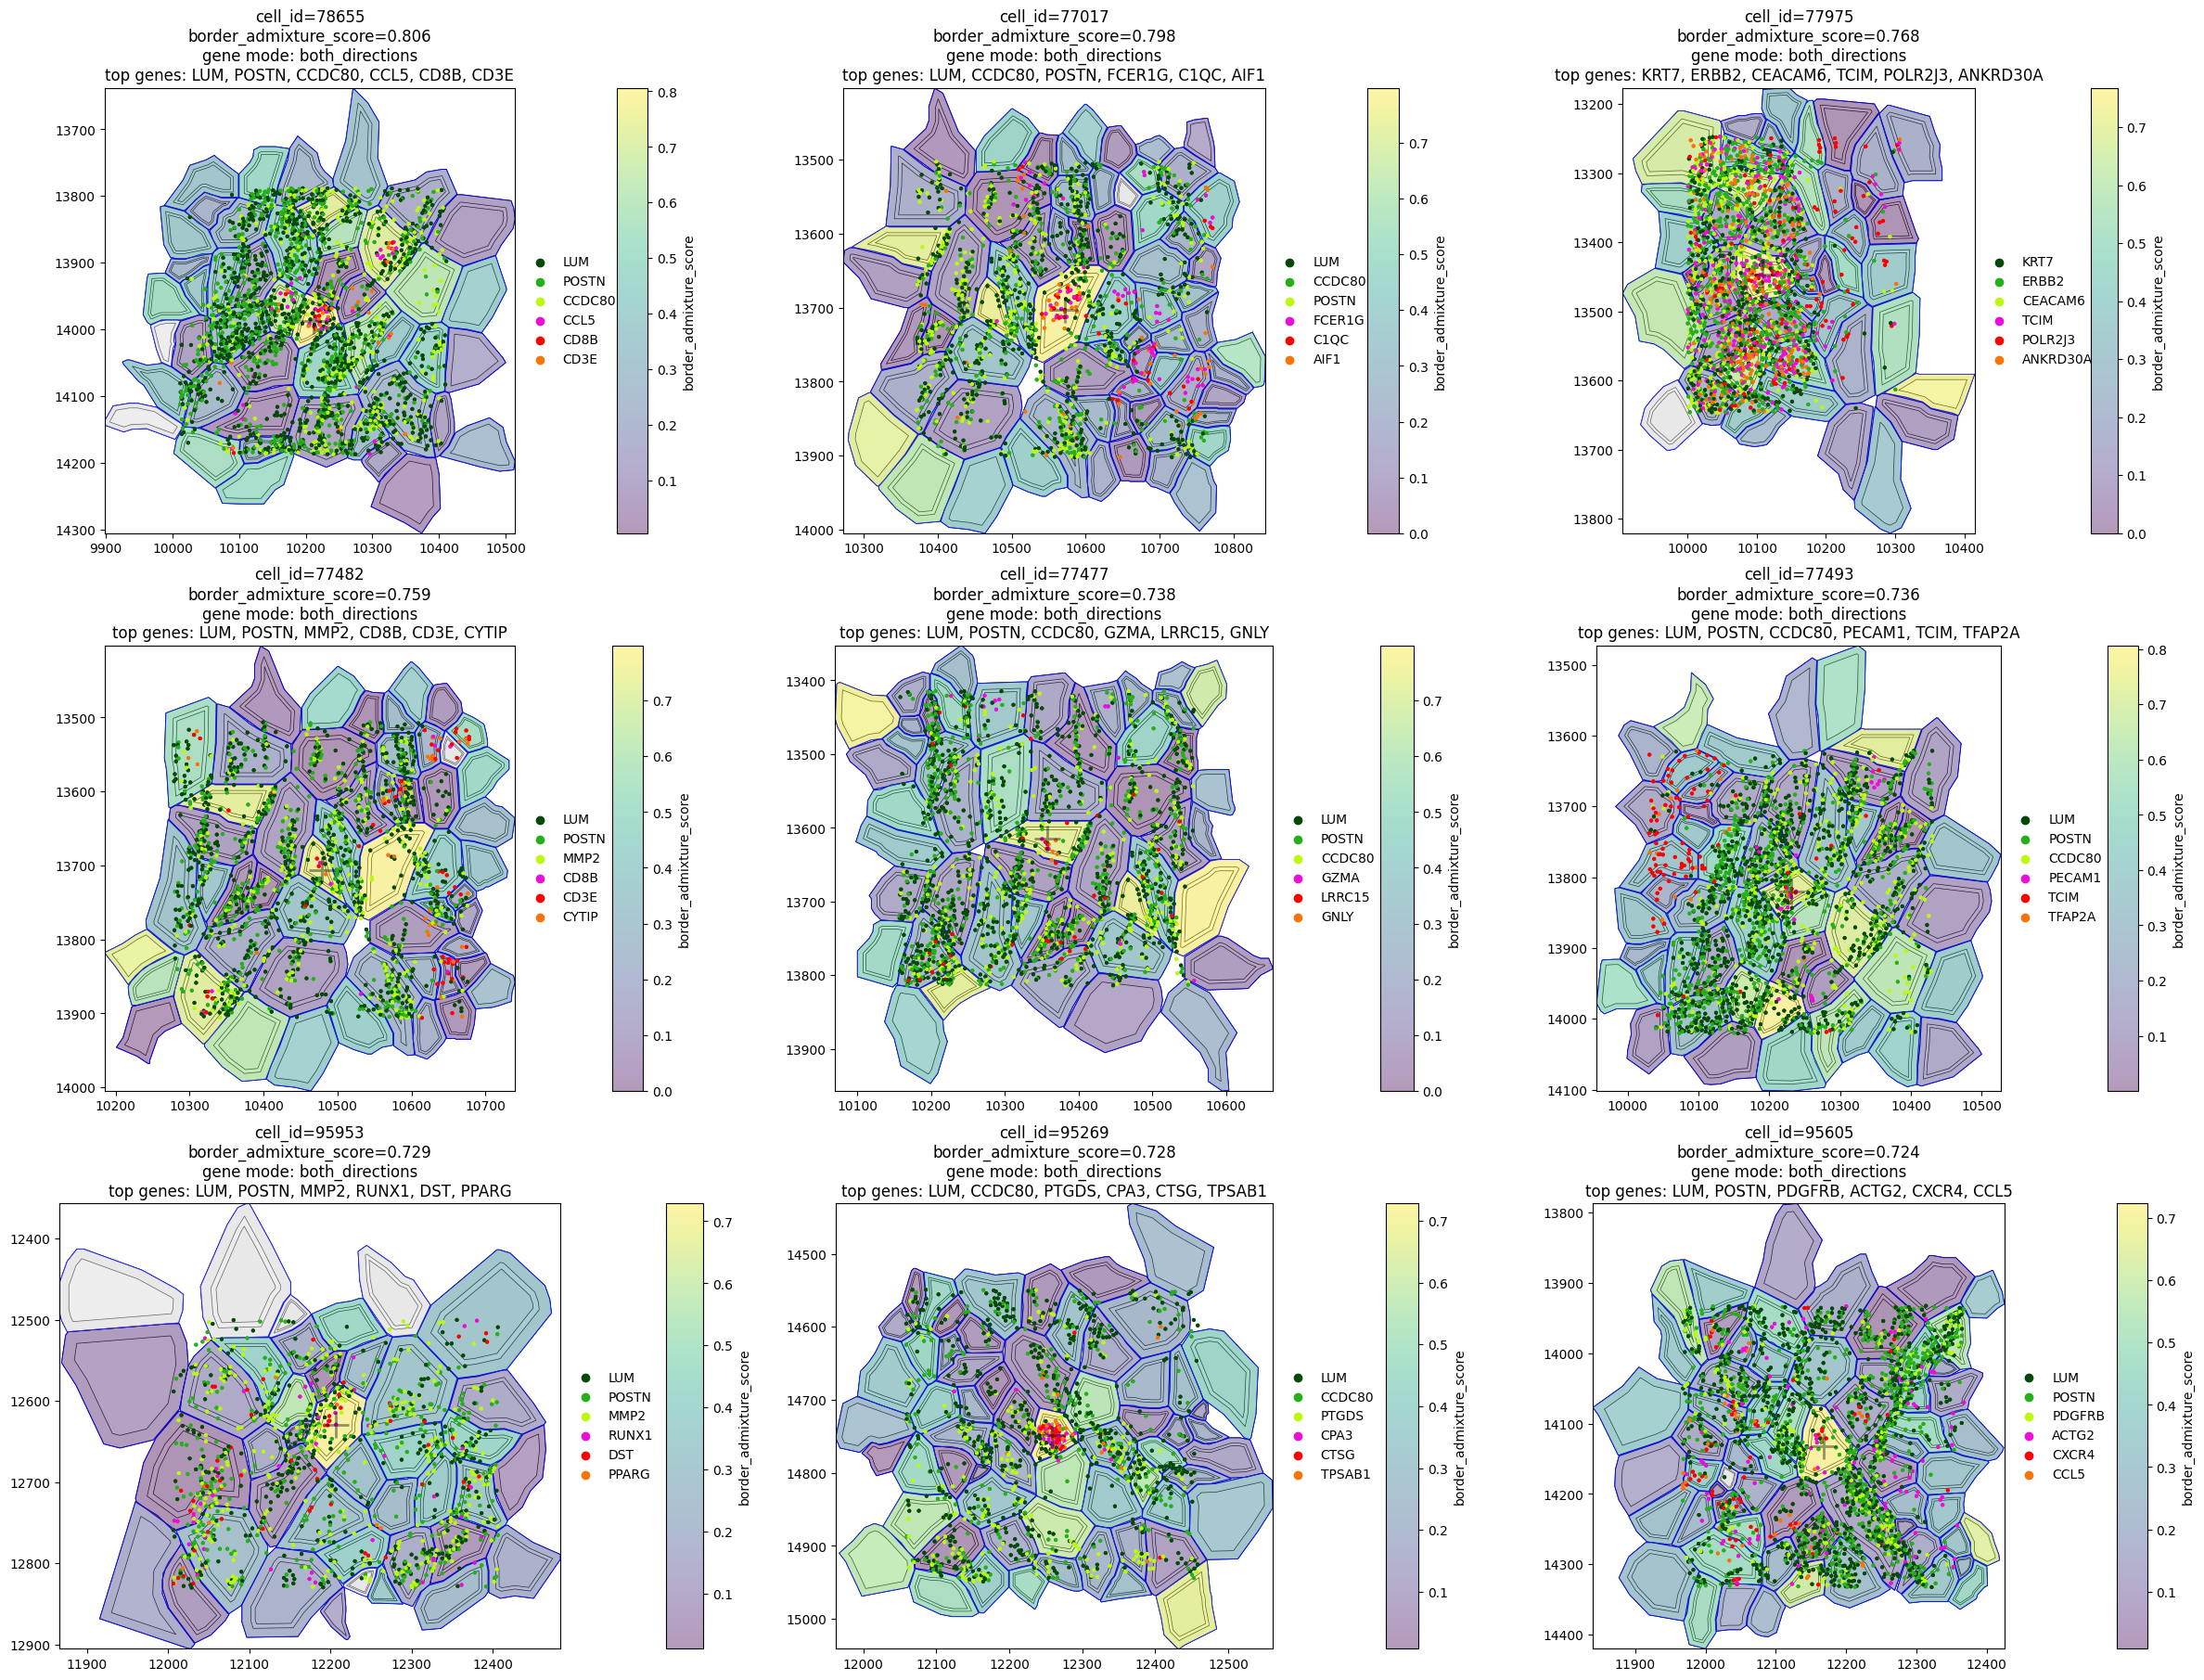

In [53]:
obs = sdata.tables['table'].obs
cell_mask = (
    obs['border_admixture_score_ci_low'] > obs['border_admixture_score'].median()    
)

plot_top_cells_by_metric(
    sdata,
    cell_mask = cell_mask,
    tables_cell_id_key="cell_id",
    points_gene_key = "feature_name",
    points_cell_id_key="cell_id",
    feature="border_admixture_score",
    gene_selection_mode="both_directions",
    #pix_to_um_scale_factor=1,
    n_cells=9,
    n_genes=6,
    padding=200,
)

In [54]:
tbl = st.sdata["table"]
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

markers[method] = segtraq.markers_from_reference(
    adata_ref,
    cell_type_key="celltype_major",
    n_jobs=16,
)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The p

In [59]:
adata_q = st.sdata[st.tables_key]
if {"centroid_x", "centroid_y"}.issubset(adata_q.obs.columns):
    nan_cells = adata_q.obs.loc[adata_q.obs[["centroid_x", "centroid_y"]].isna().any(axis=1), "cell_id"].tolist()
    if nan_cells:
        st.filter_cells(col="cell_id", func=lambda s: ~s.isin(nan_cells))


In [80]:
purity = st.sp.marker_purity(
    cell_type_key="transferred_cell_type",
    require_neighbor_expression=True,
    markers=markers[method],
    inplace=True,
)

Text(0.5, 1.0, 'negative_marker_avoidance\n$R^2$=0.024')

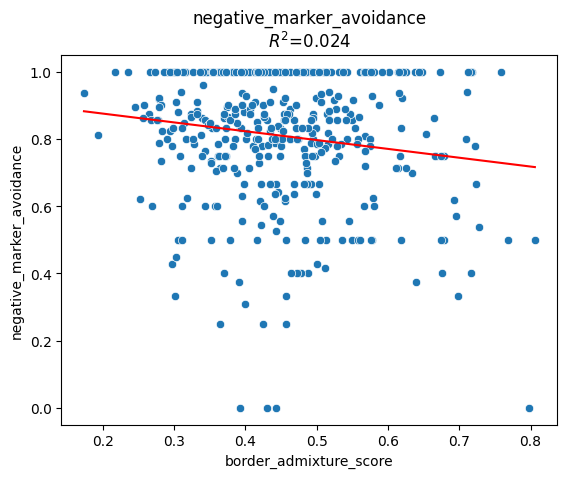

In [81]:
import seaborn as sns

x_col = "border_admixture_score"
y_col = "negative_marker_avoidance"
plot_df = st.sdata.tables["table"].obs
plot_df = plot_df[plot_df["border_admixture_score_ci_low"]>0.2]
plot_df = plot_df[[x_col, y_col]].dropna()
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit() 
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


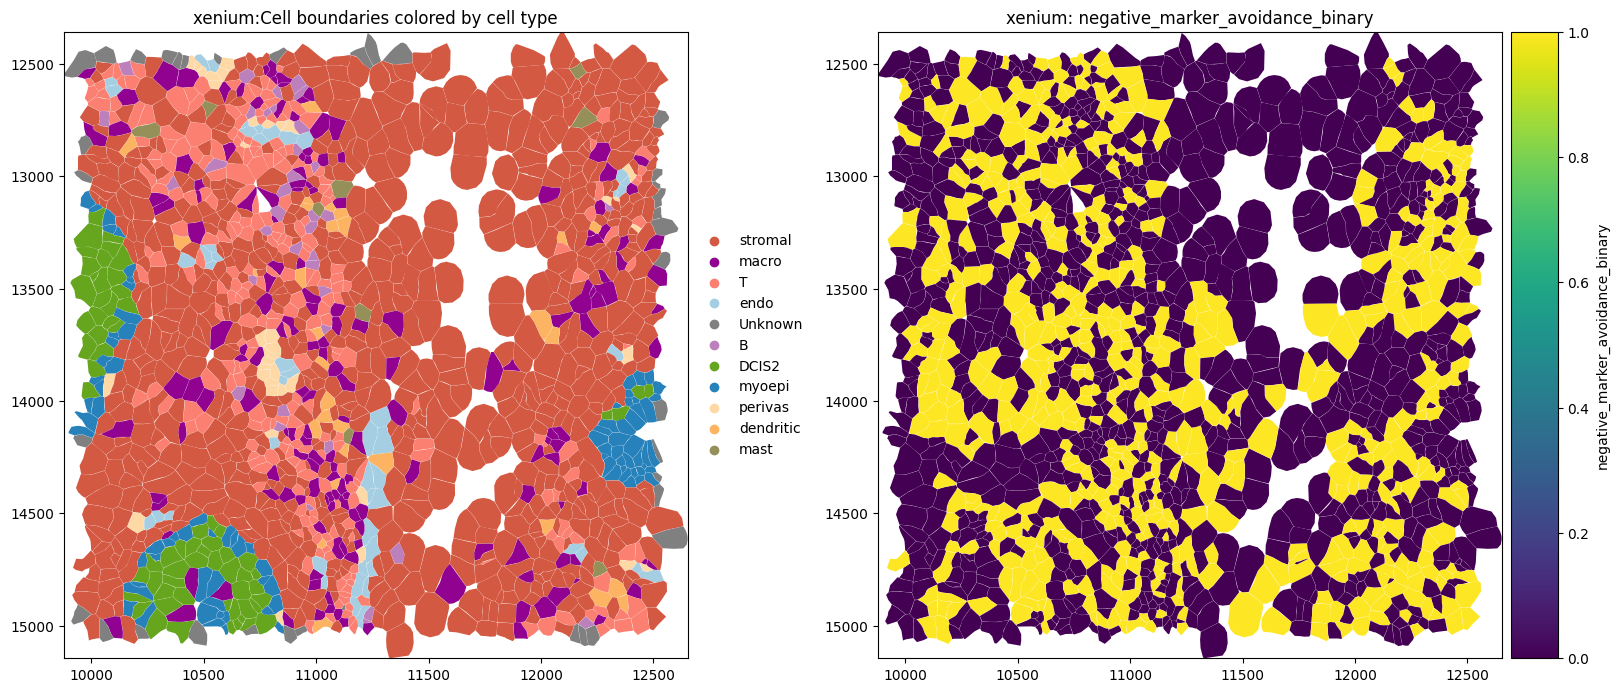

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
sdata.tables["table"].obs["negative_marker_avoidance_binary"] = sdata.tables["table"].obs["negative_marker_avoidance"] < 0.85
plot_feature_labels(sdata, "xenium", "negative_marker_avoidance_binary", axes)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 289 NaN values in color data. These observations will be colored with the 'na_color'.               


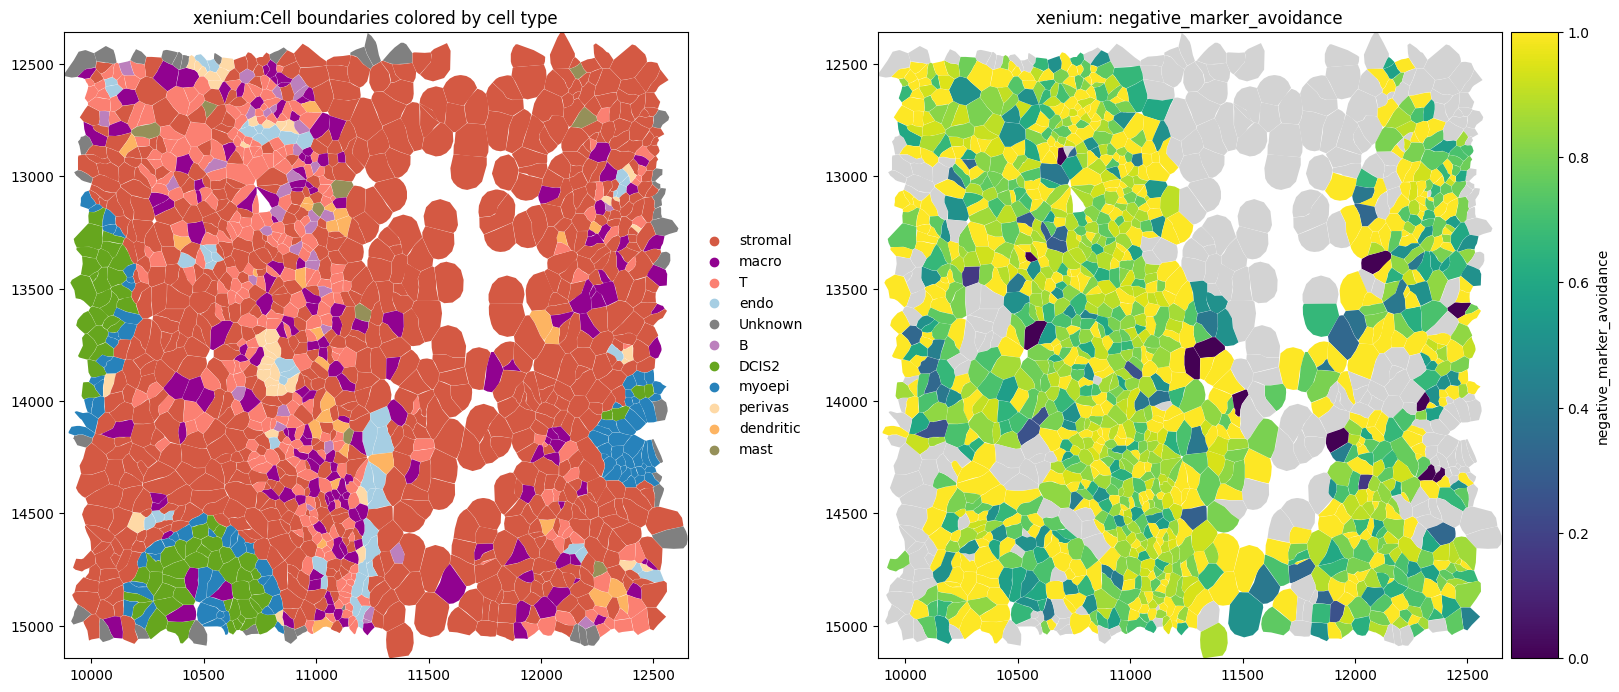

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
plot_feature_labels(sdata, "xenium", "negative_marker_avoidance", axes)

Text(0.5, 1.0, 'positive_marker_recall\n$R^2$=0.314')

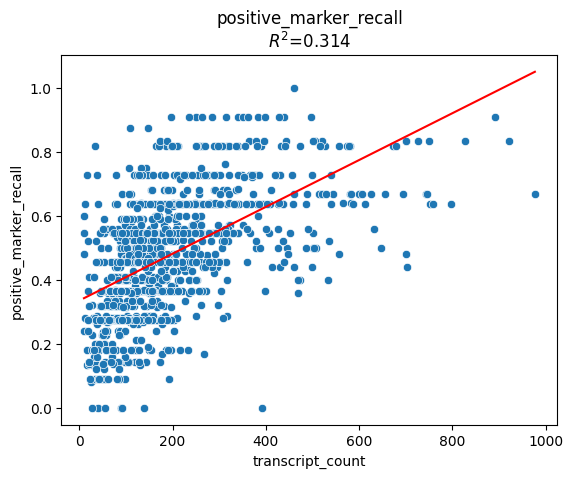

In [88]:
import seaborn as sns

x_col = "transcript_count"
y_col = "positive_marker_recall"
plot_df = st.sdata.tables["table"].obs
plot_df = plot_df[[x_col, y_col]].dropna()
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit() 
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

## Comparison of border admixture score for Xenium v1 (480 genes) and for Xenium Prime (5k genes) dataset

In [592]:
sdata_xenium = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v2_crop.zarr/")
sdata_proseg3 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v3_crop.zarr/")

In [593]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_proseg3 = segtraq.SegTraQ(
    sdata_proseg3,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


In [594]:
st_xenium.filter_control_and_low_quality_transcripts()
st_proseg2.filter_control_and_low_quality_transcripts()
st_proseg3.filter_control_and_low_quality_transcripts(min_qv=None)

In [595]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2, "proseg3": st_proseg3}

In [596]:
for method, st in st_dict.items():

    _mix_fit = st.rs.border_admixture_score()

In [223]:
def density_plot_feature(sdata_dict, features):
    all_feats = []
    for method, st in sdata_dict.items():
        feat = st.sdata["table"].obs[features]
        tmp = feat.copy()
        tmp["method"] = method
        all_feats.append(tmp)

    df = pd.concat(all_feats, ignore_index=True)
    df["method"] = df["method"].astype(str)

    feature_cols = [c for c in df.columns if c != "method"]

    plt.style.use("default")

    n = len(feature_cols)
    n_cols = min(3, n)
    n_rows = np.ceil(n / n_cols).astype(int)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 2 * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, feature_cols, strict=False):
        sns.kdeplot(data=df, x=feat, hue="method", common_norm=False, palette="Set2", fill=False, ax=ax)

    fig.tight_layout()
    plt.show()

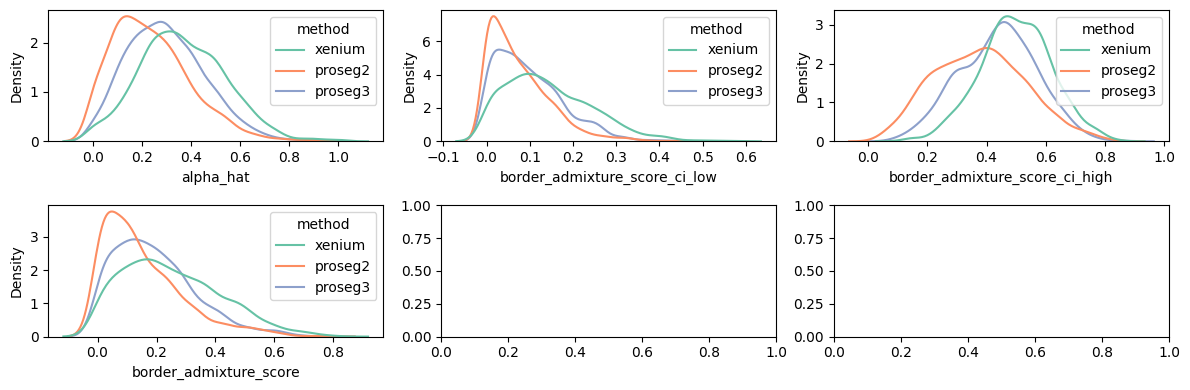

In [602]:
features = ["alpha_hat", "border_admixture_score_ci_low", "border_admixture_score_ci_high", "border_admixture_score"]
density_plot_feature(st_dict, features)

In [598]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in Proseg2: {st_proseg2.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in ProSeg3: {st_proseg3.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")

NaNs in Xenium: 1431
NaNs in Proseg2: 1276
NaNs in ProSeg3: 1249


In [599]:
print(f"Median score (Xenium): {(st_xenium.sdata.tables['table'].obs['border_admixture_score'].median())}")
print(f"Median score (Proseg2): {(st_proseg2.sdata.tables['table'].obs['border_admixture_score'].median())}")
print(f"Median score (Proseg3): {(st_proseg3.sdata.tables['table'].obs['border_admixture_score'].median())}")

Median score (Xenium): 0.22923366283305294
Median score (Proseg2): 0.11736632925323612
Median score (Proseg3): 0.17121342241935242


In [600]:
print(f"Median score for CI_low > 0.5 (Xenium): {(st_xenium.sdata.tables['table'].obs.loc[st_xenium.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")
print(f"Median score for CI_low > 0.5 (proseg2): {(st_proseg2.sdata.tables['table'].obs.loc[st_proseg2.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")
print(f"Median score for CI_low > 0.5 (Proseg3): {(st_proseg3.sdata.tables['table'].obs.loc[st_proseg3.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")

Median score for CI_low > 0.5 (Xenium): 0.493240058642006
Median score for CI_low > 0.5 (proseg2): 0.49907789447855844
Median score for CI_low > 0.5 (Proseg3): 0.4925852203057336


In [4]:
sdata_xenium_ws = sd.read_zarr("../../data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/proseg2.zarr")

no parent found for <ome_zarr.reader.Label object at 0x7ffeb5556910>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeadd98890>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaee13c50>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe7ffa0e50>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe9c538690>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeadd8e790>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe9c58c2d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe9c53bb50>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe9c5ab0d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe9c53fa10>: None


In [5]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [6]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from perfo

In [7]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1346: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: UserWarning: points_background_id '0' is not the most common cell ID among points (most common is '2022'). This may indicate that your background ID is not correctly set. If you are sure that 'points_background_id' is correct, you can ignore this warning.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1346: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes

In [8]:
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg}

In [9]:
for _, st in st_dict.items():
    st.filter_control_and_low_quality_transcripts(min_qv=20)

In [10]:
for method, st in st_dict.items():

    _mix_fit = st.rs.border_admixture_score()

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The p

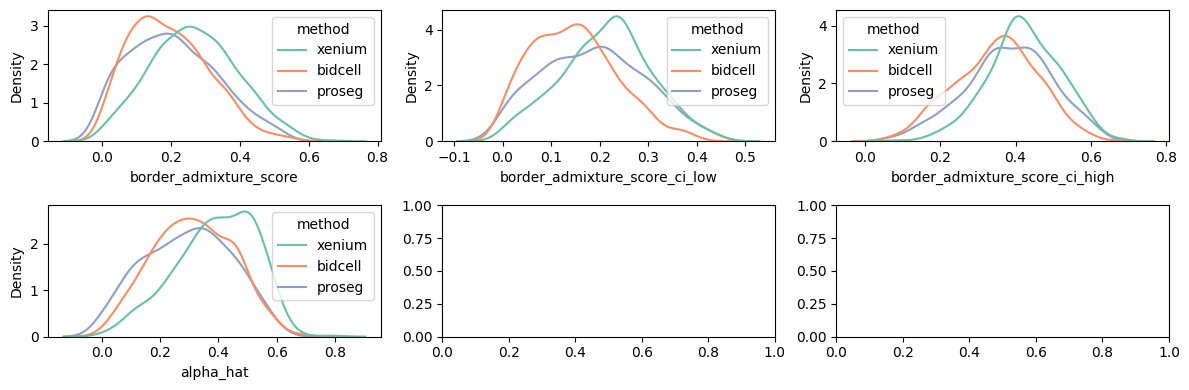

In [700]:
features = ["border_admixture_score", "border_admixture_score_ci_low", "border_admixture_score_ci_high", "alpha_hat"]
density_plot_feature(st_dict, features)

In [611]:
print(f"Median score (Xenium): {(st_xenium.sdata.tables['table'].obs['n_center'].median())}")
print(f"Median score (Xenium): {(st_xenium.sdata.tables['table'].obs['n_border'].median())}")

Median score (Xenium): 38.0
Median score (Xenium): 21.0


In [612]:
print(f"Median score for CI_low > 0.5 (Xenium): {(st_xenium.sdata.tables['table'].obs.loc[st_xenium.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")
print(f"Median score for CI_low > 0.5 (Bidcell): {(st_bidcell.sdata.tables['table'].obs.loc[st_bidcell.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")
print(f"Median score for CI_low > 0.5 (Proseg): {(st_proseg.sdata.tables['table'].obs.loc[st_proseg.sdata.tables['table'].obs['border_admixture_score_ci_low'] > 0.25, 'border_admixture_score'].median())}")

Median score for CI_low > 0.5 (Xenium): 0.3845382022092383
Median score for CI_low > 0.5 (Bidcell): 0.3662556739631967
Median score for CI_low > 0.5 (Proseg): 0.3458787477700407


In [613]:
print(f"Median score (Xenium): {(st_xenium.sdata.tables['table'].obs['border_admixture_score'].median())}")
print(f"Median score (Bidcell): {(st_bidcell.sdata.tables['table'].obs['border_admixture_score'].median())}")
print(f"Median score (Proseg): {(st_proseg.sdata.tables['table'].obs['border_admixture_score'].median())}")

Median score (Xenium): 0.2630974308944677
Median score (Bidcell): 0.183596134925611
Median score (Proseg): 0.1970000381983543


In [614]:
print(f"n_center (Xenium): {((st_xenium.sdata.tables['table'].obs['n_center']<10) | (st_xenium.sdata.tables['table'].obs['n_border']<10) | (st_xenium.sdata.tables['table'].obs['n_neighborhood'] < 10) | (st_xenium.sdata.tables['table'].obs['n_genes_used'] < 5)).sum()}")
print(f"n_center (BidCell): {((st_bidcell.sdata.tables['table'].obs['n_center']<10) | (st_bidcell.sdata.tables['table'].obs['n_border']<10) | (st_bidcell.sdata.tables['table'].obs['n_neighborhood'] < 10) | (st_bidcell.sdata.tables['table'].obs['n_genes_used'] < 5)).sum()}")
print(f"n_center (ProSeg): {((st_proseg.sdata.tables['table'].obs['n_center']<10) | (st_proseg.sdata.tables['table'].obs['n_border']<10) | (st_proseg.sdata.tables['table'].obs['n_neighborhood'] < 10) | (st_proseg.sdata.tables['table'].obs['n_genes_used'] < 5)).sum()}")

n_center (Xenium): 191
n_center (BidCell): 227
n_center (ProSeg): 310


In [615]:
print(f"n_neighbors (Xenium): {st_xenium.sdata.tables['table'].obs['n_neighbors'].mean()}")
print(f"n_neighbors (BidCell): {st_bidcell.sdata.tables['table'].obs['n_neighbors'].mean()}")
print(f"n_neighbors (ProSeg): {st_proseg.sdata.tables['table'].obs['n_neighbors'].mean()}")

n_neighbors (Xenium): 5.5339547270306255
n_neighbors (BidCell): 6.906914893617022
n_neighbors (ProSeg): 7.9346938775510205


In [616]:
st_bidcell.sdata.tables["table"].obs["n_genes_used"].mean()

np.float64(588.625)

In [617]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in BidCell: {st_bidcell.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")
print(f"NaNs in ProSeg: {st_proseg.sdata.tables['table'].obs['border_admixture_score'].notna().sum()}")

NaNs in Xenium: 560
NaNs in BidCell: 525
NaNs in ProSeg: 425


In [619]:
print(f"NaNs in Xenium: {st_xenium.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")
print(f"NaNs in BidCell: {st_bidcell.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")
print(f"NaNs in ProSeg: {st_proseg.sdata.tables['table'].obs['border_admixture_score'].isna().sum()}")

NaNs in Xenium: 191
NaNs in BidCell: 235
NaNs in ProSeg: 320


In [11]:
# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:771: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["counts"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/S

In [622]:
# method for visualization
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

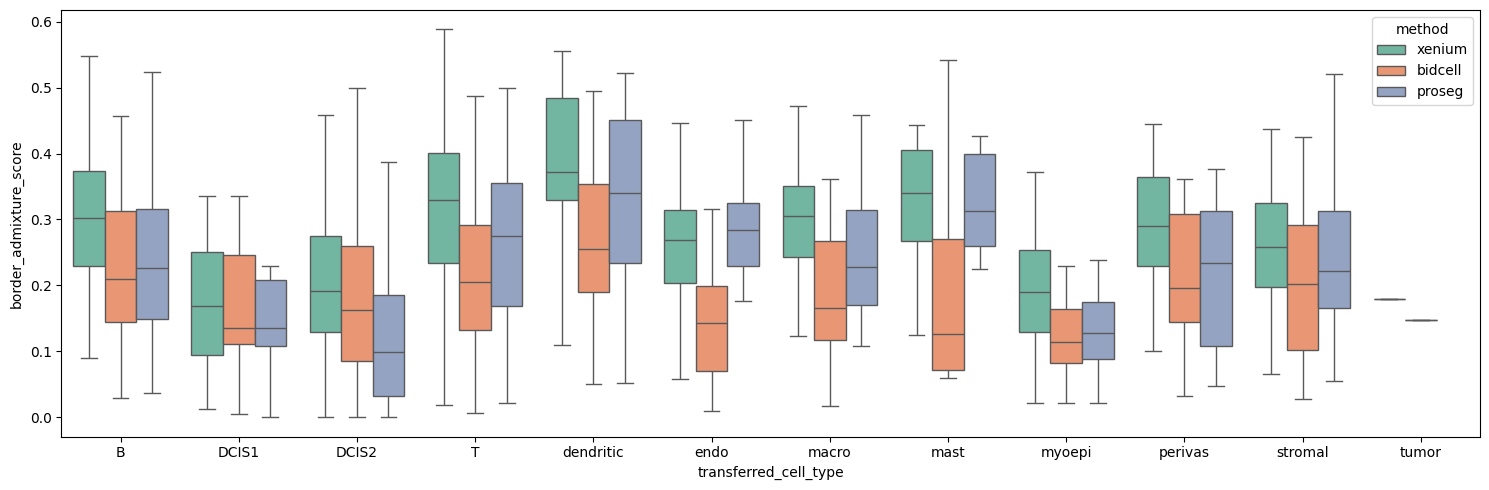

In [623]:
boxplot_per_celltype(st_dict, "border_admixture_score")

In [650]:
for method, st in st_dict.items():
    st.bl.mean_transcripts_per_gene_per_cell()

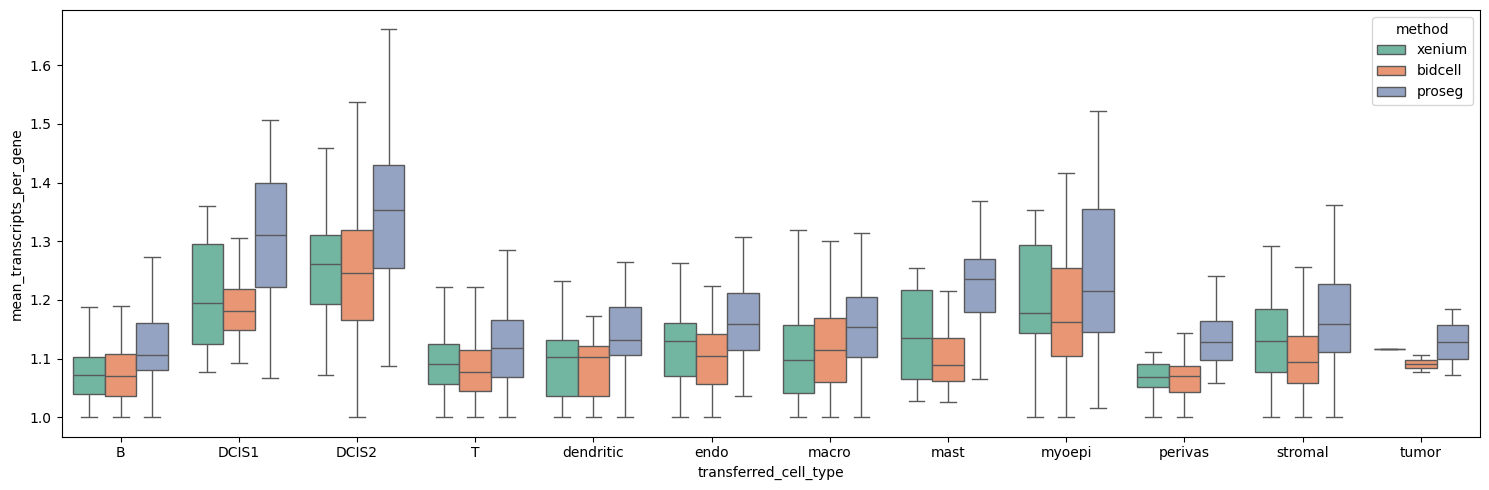

In [651]:
boxplot_per_celltype(st_dict, "mean_transcripts_per_gene")

In [12]:
markers = {}
for method, st in st_dict.items():
    tbl = st.sdata["table"]
    common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
    adata_ref = adata_ref[:, common_genes].copy()

    markers[method] = segtraq.markers_from_reference(
        adata_ref,
        cell_type_key="celltype_major",
        n_jobs=16,
    )

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The p

In [14]:
for method, st in st_dict.items():
    purity = st.sp.marker_purity(
        cell_type_key="transferred_cell_type",
        require_neighbor_expression=True,
        markers=markers[method],
        inplace=True,
    )

In [688]:
st.sdata.tables["table"].obs["positive_F1"].mean()

np.float64(0.14679193787489156)

In [690]:
st.sdata.tables["table"].obs["positive_F1"].mean()

np.float64(0.14679193787489156)

Text(0.5, 1.0, 'positive_marker_recall\n$R^2$=0.005')

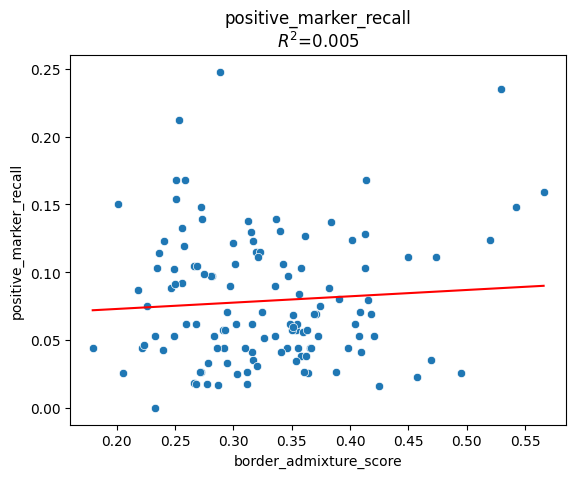

In [28]:
import seaborn as sns

x_col = "border_admixture_score"
y_col = "positive_marker_recall"
plot_df = st_bidcell.sdata.tables["table"].obs
plot_df = plot_df[plot_df["border_admixture_score_ci_low"]>0.2]
plot_df = plot_df[[x_col, y_col]].dropna()
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit() 
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

Text(0.5, 1.0, 'negative_marker_avoidance\n$R^2$=0.037')

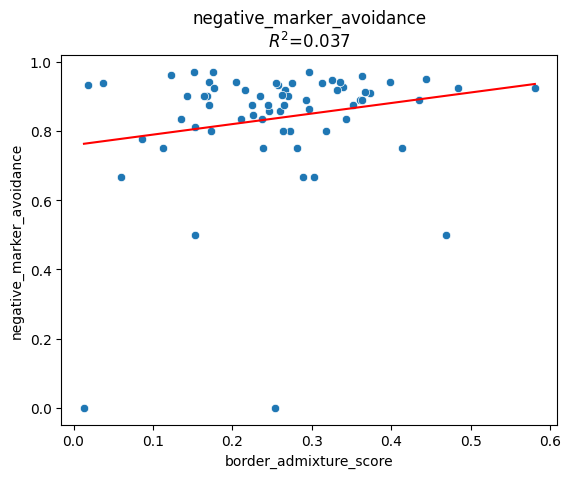

In [27]:
x_col = "border_admixture_score"
y_col = "negative_marker_avoidance"
plot_df = st_xenium.sdata.tables["table"].obs
#plot_df = plot_df[plot_df["border_admixture_score_ci_low"]>0.2]
plot_df = plot_df[[x_col, y_col]].dropna()
plot_df = plot_df[plot_df[y_col]<1]
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit()
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

In [25]:
st_xenium.sdata.tables["table"].obs["transcript_rank"] = st_xenium.sdata.tables["table"].obs["transcript_count"].rank(method="first", ascending=True)

Text(0.5, 1.0, 'negative_marker_avoidance\n$R^2$=0.013')

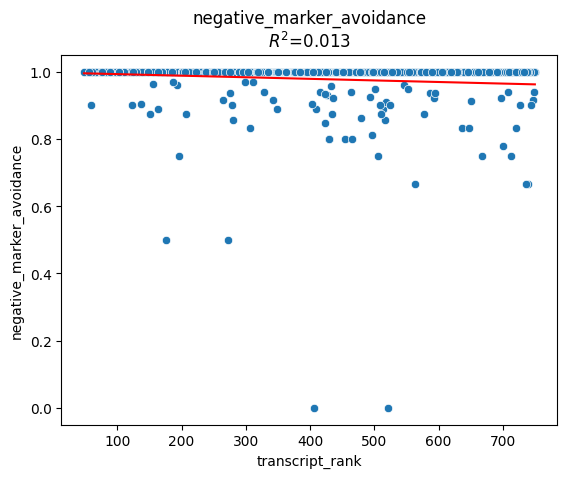

In [26]:
y_col = "negative_marker_avoidance"
x_col = "transcript_rank"
plot_df = st_xenium.sdata.tables["table"].obs
plot_df = plot_df[[x_col, y_col]].dropna()
#plot_df = plot_df[plot_df[y_col]>0]
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit()
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

Text(0.5, 1.0, 'n_evaluated_positive_markers\n$R^2$=0.219')

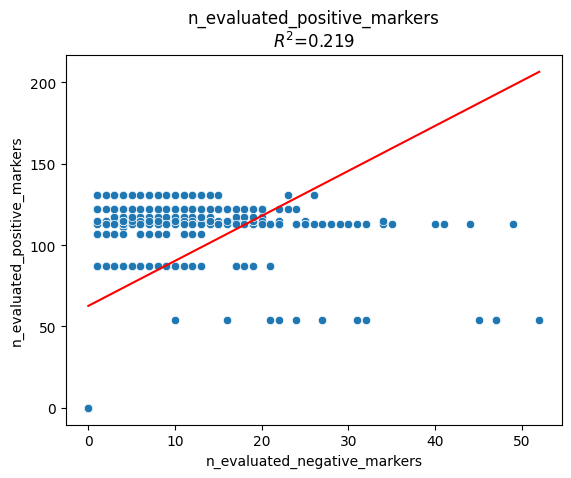

In [23]:
y_col = "n_evaluated_positive_markers"
x_col = "n_evaluated_negative_markers"
plot_df = st_xenium.sdata.tables["table"].obs
plot_df = plot_df[[x_col, y_col]].dropna()
#plot_df = plot_df[plot_df[y_col]<1]
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit()
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

Text(0.5, 1.0, 'negative_F1\n$R^2$=0.015')

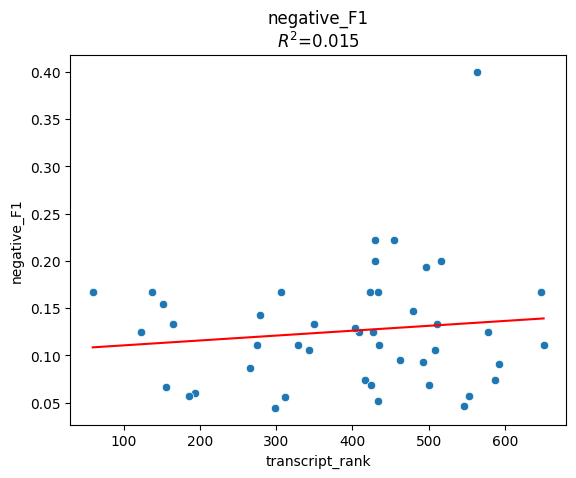

In [676]:
y_col = "negative_F1"
x_col = "transcript_rank"
plot_df = st_xenium.sdata.tables["table"].obs
plot_df = plot_df[[x_col, y_col]].dropna()
plot_df = plot_df[plot_df[y_col]>0]
fig =sns.scatterplot(plot_df, x=x_col, y=y_col)

X = sm.add_constant(plot_df[x_col].to_numpy())
y = plot_df[y_col].to_numpy()

model = sm.OLS(y, X, missing="drop").fit()
r2 = model.rsquared

xs = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 200)
ys = model.predict(sm.add_constant(xs))

fig.plot(xs, ys, color="red")
title = f"{y_col}\n$R^2$={r2:.3f}"
fig.set_title(title)

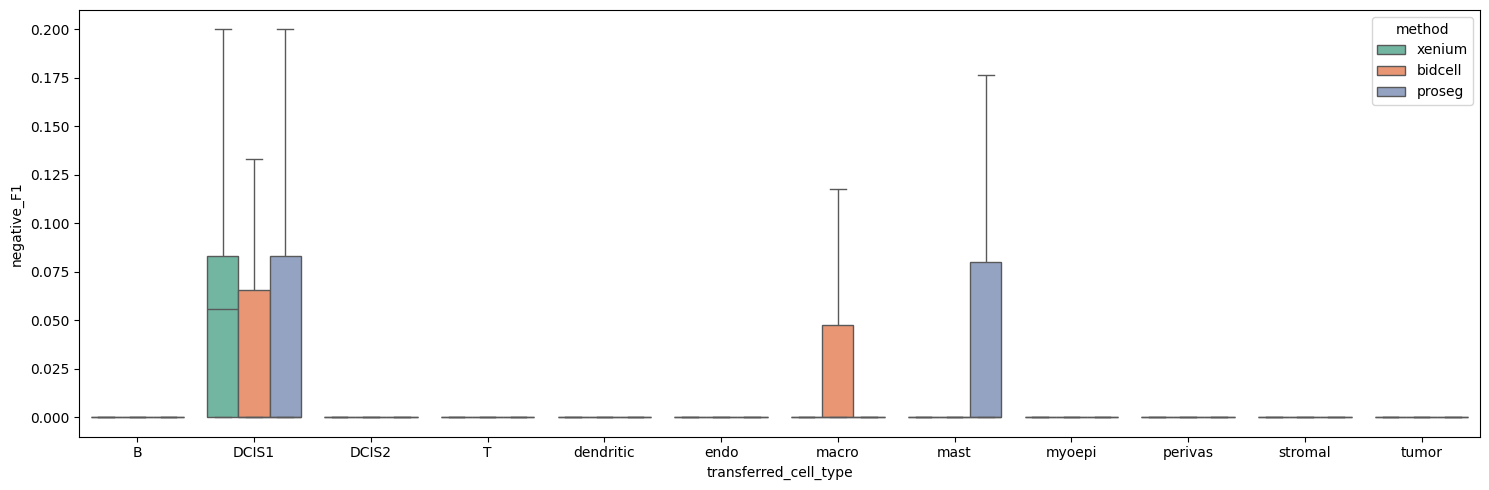

In [269]:
boxplot_per_celltype(st_dict, "negative_F1")

In [ ]:
print(f"negative_F1 (Xenium): {st_xenium.sdata.tables['table'].obs['negative_F1'].mean()}")
print(f"negative_F1 (BidCell): {st_bidcell.sdata.tables['table'].obs['negative_F1'].mean()}")
print(f"negative_F1 (ProSeg): {st_proseg.sdata.tables['table'].obs['negative_F1'].mean()}")

negative_F1 (Xenium): 0.013848325355628487
negative_F1 (BidCell): 0.016686688248376855
negative_F1 (ProSeg): 0.012354737385910605


In [271]:
print(
    "negative_F1 (Xenium):",
    st_xenium.sdata.tables["table"].obs.loc[
        st_xenium.sdata.tables["table"].obs["negative_F1"] > 0, "negative_F1"
    ].mean()
)

print(
    "negative_F1 (BidCell):",
    st_bidcell.sdata.tables["table"].obs.loc[
        st_bidcell.sdata.tables["table"].obs["negative_F1"] > 0, "negative_F1"
    ].mean()
)

print(
    "negative_F1 (ProSeg):",
    st_proseg.sdata.tables["table"].obs.loc[
        st_proseg.sdata.tables["table"].obs["negative_F1"] > 0, "negative_F1"
    ].mean()
)

negative_F1 (Xenium): 0.11020146233704356
negative_F1 (BidCell): 0.11111817401760042
negative_F1 (ProSeg): 0.13229864617412607


In [640]:
for method, st in st_dict.items():
    st.sp.neighbor_contamination(cell_type_key="transferred_cell_type", markers=markers[method])
    st.sdata.tables["table"].obs["negative_marker_contamination_counts_scaled"] = st.sdata.tables["table"].obs["negative_marker_contamination_counts"] / st.sdata.tables["table"].obs["transcript_count"]

In [274]:
print(f"negative_marker_contamination_counts (Xenium): {st_xenium.sdata.tables['table'].obs['negative_marker_contamination_counts'].mean()}")
print(f"negative_marker_contamination_counts (BidCell): {st_bidcell.sdata.tables['table'].obs['negative_marker_contamination_counts'].mean()}")
print(f"negative_marker_contamination_counts (ProSeg): {st_proseg.sdata.tables['table'].obs['negative_marker_contamination_counts'].mean()}")

negative_marker_contamination_counts (Xenium): 0.19469026548672566
negative_marker_contamination_counts (BidCell): 0.23720136518771331
negative_marker_contamination_counts (ProSeg): 0.13813229571984437


In [278]:
print(f"negative_marker_contamination_counts_scaled (Xenium): {st_xenium.sdata.tables['table'].obs['negative_marker_contamination_counts_scaled'].mean()}")
print(f"negative_marker_contamination_counts_scaled (BidCell): {st_bidcell.sdata.tables['table'].obs['negative_marker_contamination_counts_scaled'].mean()}")
print(f"negative_marker_contamination_counts_scaled (ProSeg): {st_proseg.sdata.tables['table'].obs['negative_marker_contamination_counts_scaled'].mean()}")

negative_marker_contamination_counts_scaled (Xenium): 0.0024994662223063024
negative_marker_contamination_counts_scaled (BidCell): 0.0026966942019818452
negative_marker_contamination_counts_scaled (ProSeg): 0.002226648923847053


In [276]:
print(
    "negative_marker_contamination_counts (Xenium):",
    st_xenium.sdata.tables["table"].obs.loc[
        st_xenium.sdata.tables["table"].obs["negative_marker_contamination_counts"] > 0, "negative_marker_contamination_counts"
    ].mean()
)

print(
    "negative_marker_contamination_counts (BidCell):",
    st_bidcell.sdata.tables["table"].obs.loc[
        st_bidcell.sdata.tables["table"].obs["negative_marker_contamination_counts"] > 0, "negative_marker_contamination_counts"
    ].mean()
)

print(
    "negative_marker_contamination_counts (ProSeg):",
    st_proseg.sdata.tables["table"].obs.loc[
        st_proseg.sdata.tables["table"].obs["negative_marker_contamination_counts"] > 0, "negative_marker_contamination_counts"
    ].mean()
)

negative_marker_contamination_counts (Xenium): 1.5492957746478873
negative_marker_contamination_counts (BidCell): 1.5795454545454546
negative_marker_contamination_counts (ProSeg): 1.4791666666666667


In [279]:
markers = {}

for method, st in st_dict.items():
    tbl = st.sdata["table"]
    common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
    adata_ref = adata_ref[:, common_genes].copy()

    markers[method] = segtraq.markers_from_reference(
        adata_ref,
        cell_type_key="celltype_major",
        min_pos_frac=0.3,
        n_jobs=16,
    )

    mecr = st.sp.mutually_exclusive_coexpression_rate(
        markers=markers[method],
    )

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The p

/scratch/jobs/52952712/ipykernel_1322611/4282967003.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/jobs/52952712/ipykernel_1322611/4282967003.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


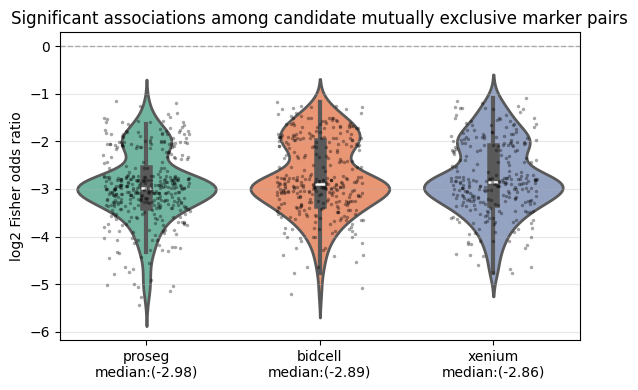

In [280]:
rows = []

for method, st in st_dict.items():
    tbl = st.sdata.tables["table"]
    mecr_df = tbl.uns["mutually_exclusive_coexpression_rate"]

    # Filter significant, finite odds ratios and p-values
    df_sig = mecr_df[
        mecr_df["odds_ratio"].notna()
        & np.isfinite(mecr_df["odds_ratio"])
        & mecr_df["pvalue"].notna()
        & np.isfinite(mecr_df["pvalue"])
        & (mecr_df["pvalue"] < 0.05)
    ]

    # Build rows
    rows.extend({"method": str(method), "Fisher_OR": np.log2(row["odds_ratio"])} for _, row in df_sig.iterrows())

df = pd.DataFrame(rows)

median_order = df.groupby("method")["Fisher_OR"].median().sort_values().index.tolist()
medians = df.groupby("method")["Fisher_OR"].median().reindex(median_order)

xtick_labels = [f"{m}\nmedian:({medians[m]:.2f})" for m in median_order]

plt.figure(figsize=(6, 4))

ax = sns.violinplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    palette="Set2",
    linewidth=2,
)

sns.stripplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    color="black",
    size=2.5,
    alpha=0.35,
    jitter=0.25,
    ax=ax,
)

# Reference line: OR = 1
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.6)

ax.set_xticklabels(xtick_labels)

ax.set_ylabel("log2 Fisher odds ratio")
ax.set_xlabel("")
ax.set_title("Significant associations among candidate mutually exclusive marker pairs")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()